In [38]:
# Load feature helpers
%run feature_engineering_helper.py

# Load panel experiment helpers
%run experiment_helper.py

## Read data

In [2]:
df = make_tiny_df()

In [3]:
df

,store_id,week_start,GC,digital_promo_1,digital_promo_2,digital_promo_3,digital_promo_4,digital_promo_5,media_1,media_2,media_3,media_4,media_5
0,1,2023-01-01,7762.164881,0.392485,0.877477,0.531428,0.138708,0.863492,61326.061549,17201.343184,97417.410477,71648.944633,3607.031881
1,1,2023-01-08,4444.896554,0.923900,0.959596,0.586109,0.293273,0.240285,3988.161026,67742.162031,5269.544085,62586.983836,16846.864943
2,1,2023-01-15,8600.119407,0.578978,0.228336,0.510166,0.305943,0.839874,12813.036067,2574.355308,79595.063348,65263.859444,41218.643405
3,1,2023-01-22,7003.943488,0.004619,0.931824,0.036025,0.261298,0.078545,50045.750273,16101.731418,64607.084138,17677.173940,71819.519391
4,1,2023-01-29,1032.355744,0.038542,0.571213,0.497091,0.460761,0.159928,74659.258456,90270.550139,26217.482191,66950.482733,36412.155677
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,10,2025-06-01,9282.298110,0.494260,0.560057,0.626922,0.845786,0.792066,39787.334767,6773.695983,913.135423,53610.359616,88195.150862
1306,10,2025-06-08,6014.205838,0.197482,0.536615,0.184140,0.035530,0.196871,61258.024739,48449.102347,63222.581574,5875.828796,31326.684255
1307,10,2025-06-15,6722.581824,0.860886,0.828648,0.107689,0.559509,0.242228,12548.255828,43434.769555,32306.555176,17573.507161,63274.505705
1308,10,2025-06-22,620.502304,0.823068,0.138851,0.437612,0.721622,0.841589,16337.065503,19778.196930,77309.609239,78198.384217,37931.698244


## Quality check

### Stats distribution check

In [4]:
feature_statistics_table(df)

,feature,count,unique,missing,missing_pct,min,max,1%,25%,50%,mean,75%,99%
0,store_id,1310,10,0,0.0,1,10,1.0,3.0,5.5,5.5,8.0,10.0
1,week_start,1310,131,0,0.0,2023-01-01 00:00:00,2025-06-29 00:00:00,2023-01-08 00:00:00,2023-08-13 00:00:00,2024-03-31 00:00:00,2024-03-31 00:00:00,2024-11-17 00:00:00,2025-06-22 00:00:00
2,GC,1310,1310,0,0.0,105.135567,9994.276901,207.607047,2490.243857,4977.943798,5029.04626,7575.148532,9918.866776
3,digital_promo_1,1310,1310,0,0.0,0.000568,0.999765,0.015803,0.247524,0.496353,0.500962,0.758843,0.991205
4,digital_promo_2,1310,1310,0,0.0,0.000642,0.999409,0.007721,0.249796,0.50597,0.5006,0.749676,0.988423
5,digital_promo_3,1310,1310,0,0.0,0.000926,0.999715,0.007617,0.230796,0.466886,0.476638,0.714848,0.991833
6,digital_promo_4,1310,1310,0,0.0,0.000314,0.999489,0.012247,0.245068,0.497942,0.49482,0.746274,0.991737
7,digital_promo_5,1310,1310,0,0.0,0.000955,0.999977,0.008484,0.264318,0.509174,0.503123,0.741319,0.990475
8,media_1,1310,1310,0,0.0,209.098224,99492.780792,961.603823,25824.248785,51041.746608,50601.296022,74774.456861,98469.2843
9,media_2,1310,1310,0,0.0,101.315539,99946.66443,746.824349,23629.896751,50922.001718,49552.93592,73797.496152,98924.662456


### Correlation VIF check

In [5]:
# Correlation matrix, vs-target correlation, and VIF
cols = df.columns.tolist()
feature_cols = [c for c in cols if c not in ("GC", "store_id", "week_start")]

pairwise_corr, target_corr, vif_table = feature_correlation_and_vif_diagnostics(
    df,
    features=feature_cols,
    target="GC",
    dropna=True,
)

display(pairwise_corr)
display(target_corr)
display(vif_table)

,digital_promo_1,digital_promo_2,digital_promo_3,digital_promo_4,digital_promo_5,media_1,media_2,media_3,media_4,media_5
digital_promo_1,1.000000,-0.028566,0.017074,0.004515,0.027673,-0.032087,0.001191,0.006201,-0.008582,-0.026452
digital_promo_2,-0.028566,1.000000,0.034746,0.020022,-0.002817,-0.018592,0.037848,-0.073663,-0.008679,0.003990
digital_promo_3,0.017074,0.034746,1.000000,0.017607,0.008017,-0.019897,-0.014277,0.018750,0.016999,0.003565
digital_promo_4,0.004515,0.020022,0.017607,1.000000,0.024779,0.040342,0.033092,-0.023547,0.002882,0.057189
digital_promo_5,0.027673,-0.002817,0.008017,0.024779,1.000000,-0.002177,-0.039595,0.003804,-0.005466,-0.009843
media_1,-0.032087,-0.018592,-0.019897,0.040342,-0.002177,1.000000,0.002037,0.051146,-0.013902,0.016857
media_2,0.001191,0.037848,-0.014277,0.033092,-0.039595,0.002037,1.000000,-0.013846,0.032475,0.030036
media_3,0.006201,-0.073663,0.018750,-0.023547,0.003804,0.051146,-0.013846,1.000000,-0.033601,0.004832
media_4,-0.008582,-0.008679,0.016999,0.002882,-0.005466,-0.013902,0.032475,-0.033601,1.000000,0.043397
media_5,-0.026452,0.003990,0.003565,0.057189,-0.009843,0.016857,0.030036,0.004832,0.043397,1.000000


,feature,corr_with_GC
0,digital_promo_1,-0.015603
1,digital_promo_2,-0.005531
2,digital_promo_3,0.004204
3,digital_promo_4,-0.008477
4,digital_promo_5,0.083325
5,media_1,0.038518
6,media_2,-0.023469
7,media_3,-0.028601
8,media_4,0.046853
9,media_5,0.015661


,feature,vif
0,digital_promo_1,3.560697
1,digital_promo_2,3.609128
2,digital_promo_3,3.543238
3,digital_promo_4,3.712486
4,digital_promo_5,3.700964
5,media_1,3.718927
6,media_2,3.583998
7,media_3,3.670796
8,media_4,3.691944
9,media_5,3.841406


In [6]:
var_ls = select_features_by_corr_and_vif(
    pairwise_corr,
    target_corr,
    vif_table,
    max_pairwise_corr= 0.073,	 #0.9,  # drop one of each highly correlated pair (weaker vs target)
    max_vif= 3.8, #5.0,             # drop remaining features with VIF above this
    verbose=True,
)

var_ls

Remove 'digital_promo_2' due to high pairwise corr |-0.074| > 0.073 with 'media_3' (corr with target: digital_promo_2=0.006, media_3=0.029)
Remove 'media_5' due to VIF=3.841 > 3.8
Selected features after filtering: ['media_3', 'digital_promo_5', 'media_1', 'media_4', 'digital_promo_3', 'media_2', 'digital_promo_1', 'digital_promo_4']


['media_3',
 'digital_promo_5',
 'media_1',
 'media_4',
 'digital_promo_3',
 'media_2',
 'digital_promo_1',
 'digital_promo_4']

Feature engineering

In [8]:
base_ls = ["GC", "store_id", "week_start"]

df2 = df[base_ls + var_ls].copy()

In [9]:
# # 1) Missing values
# # Exclude id / time keys from imputation (use membership, not c != [list]).
# _exclude = {"store_id", "week_start", 'seas_sin1', 'seas_cos1'}
# cols = [c for c in df2.columns if c not in _exclude]

# df2, imputation_medians = add_missing_imputation_features(
#     df2,
#     cols=cols,
#     strategy="median+indicator",
# )

# 2) Seasonality
df2 = add_seasonality_features(df2, "week_start", seasonality="fourier_1")

# # 3) Trend
# df = add_trend_features(df, "week_start", trend="linear", unit="week")

df2 = add_log_features(df2, features = var_ls + ["GC"])

In [11]:
var_ls

['media_3',
 'digital_promo_5',
 'media_1',
 'media_4',
 'digital_promo_3',
 'media_2',
 'digital_promo_1',
 'digital_promo_4']

In [10]:
df2.columns

Index(['GC', 'store_id', 'week_start', 'media_3', 'digital_promo_5', 'media_1',
       'media_4', 'digital_promo_3', 'media_2', 'digital_promo_1',
       'digital_promo_4', 'seas_sin1', 'seas_cos1', 'media_3_log',
       'digital_promo_5_log', 'media_1_log', 'media_4_log',
       'digital_promo_3_log', 'media_2_log', 'digital_promo_1_log',
       'digital_promo_4_log', 'GC_log'],
      dtype='object')

In [12]:
df

,store_id,week_start,GC,digital_promo_1,digital_promo_2,digital_promo_3,digital_promo_4,digital_promo_5,media_1,media_2,media_3,media_4,media_5
0,1,2023-01-01,7762.164881,0.392485,0.877477,0.531428,0.138708,0.863492,61326.061549,17201.343184,97417.410477,71648.944633,3607.031881
1,1,2023-01-08,4444.896554,0.923900,0.959596,0.586109,0.293273,0.240285,3988.161026,67742.162031,5269.544085,62586.983836,16846.864943
2,1,2023-01-15,8600.119407,0.578978,0.228336,0.510166,0.305943,0.839874,12813.036067,2574.355308,79595.063348,65263.859444,41218.643405
3,1,2023-01-22,7003.943488,0.004619,0.931824,0.036025,0.261298,0.078545,50045.750273,16101.731418,64607.084138,17677.173940,71819.519391
4,1,2023-01-29,1032.355744,0.038542,0.571213,0.497091,0.460761,0.159928,74659.258456,90270.550139,26217.482191,66950.482733,36412.155677
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,10,2025-06-01,9282.298110,0.494260,0.560057,0.626922,0.845786,0.792066,39787.334767,6773.695983,913.135423,53610.359616,88195.150862
1306,10,2025-06-08,6014.205838,0.197482,0.536615,0.184140,0.035530,0.196871,61258.024739,48449.102347,63222.581574,5875.828796,31326.684255
1307,10,2025-06-15,6722.581824,0.860886,0.828648,0.107689,0.559509,0.242228,12548.255828,43434.769555,32306.555176,17573.507161,63274.505705
1308,10,2025-06-22,620.502304,0.823068,0.138851,0.437612,0.721622,0.841589,16337.065503,19778.196930,77309.609239,78198.384217,37931.698244


In [13]:
df2

,GC,store_id,week_start,media_3,digital_promo_5,media_1,media_4,digital_promo_3,media_2,digital_promo_1,...,seas_cos1,media_3_log,digital_promo_5_log,media_1_log,media_4_log,digital_promo_3_log,media_2_log,digital_promo_1_log,digital_promo_4_log,GC_log
0,7762.164881,1,2023-01-01,97417.410477,0.863492,61326.061549,71648.944633,0.531428,17201.343184,0.392485,...,0.992709,11.486760,-0.146771,11.023960,11.179534,-0.632187,9.752743,-0.935258,-1.975387,8.957017
1,4444.896554,1,2023-01-08,5269.544085,0.240285,3988.161026,62586.983836,0.586109,67742.162031,0.923900,...,1.000000,8.569699,-1.425931,8.291086,11.044313,-0.534249,11.123464,-0.079151,-1.226650,8.399512
2,8600.119407,1,2023-01-15,79595.063348,0.839874,12813.036067,65263.859444,0.510166,2574.355308,0.578978,...,0.992709,11.284707,-0.174503,9.458218,11.086194,-0.673019,7.853354,-0.546492,-1.184356,9.059531
3,7003.943488,1,2023-01-22,64607.084138,0.078545,50045.750273,17677.173940,0.036025,16101.731418,0.004619,...,0.970942,11.076079,-2.544084,10.820693,9.780029,-3.323545,9.686682,-5.377621,-1.342093,8.854229
4,1032.355744,1,2023-01-29,26217.482191,0.159928,74659.258456,66950.482733,0.497091,90270.550139,0.038542,...,0.935016,10.174182,-1.833034,11.220690,11.111709,-0.698983,11.410567,-3.256007,-0.774875,6.939599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,9282.298110,10,2025-06-01,913.135423,0.792066,39787.334767,53610.359616,0.626922,6773.695983,0.494260,...,-0.822984,6.816884,-0.233111,10.591304,10.889498,-0.466933,8.820802,-0.704694,-0.167489,9.135864
1306,6014.205838,10,2025-06-08,63222.581574,0.196871,61258.024739,5875.828796,0.184140,48449.102347,0.197482,...,-0.885456,11.054417,-1.625207,11.022850,8.678602,-1.692058,10.788269,-1.622108,-3.337380,8.701880
1307,6722.581824,10,2025-06-15,32306.555176,0.242228,12548.255828,17573.507161,0.107689,43434.769555,0.860886,...,-0.935016,10.383025,-1.417874,9.437337,9.774148,-2.228507,10.679016,-0.149793,-0.580695,8.813228
1308,620.502304,10,2025-06-22,77309.609239,0.841589,16337.065503,78198.384217,0.437612,19778.196930,0.823068,...,-0.970942,11.255574,-0.172464,9.701192,11.267004,-0.826423,9.892335,-0.194717,-0.326254,6.430529


### MLflow experiments (FE & Mundlak)

Loads `experiment_helper.py`: nested runs for each **feature set × panel estimator** (`fe` / `mundlak`), with optional **seasonality + trend** controls from `feature_engineering_helper`.

In [17]:
# Time window split (must overlap df['week_start'] — make_tiny_df uses 2023-01-01 .. 2025-06-30)
time_splits = [
    TimeSplit(
        time_split_id="train2023_24__test2025_H1",
        train_start="2023-01-01",
        train_end="2024-12-31",
        test_start="2025-01-01",
        test_end="2025-06-30",
    ),
    TimeSplit(
        time_split_id="train2024_only__test2025_H1",
        train_start="2023-01-01",
        train_end="2024-11-30",
        test_start="2025-01-01",
        test_end="2025-06-30",
    ),
    TimeSplit(
        time_split_id="train2024_only__test2025_H1",
        train_start="2023-01-01",
        train_end="2024-10-31",
        test_start="2025-01-01",
        test_end="2025-06-30",
    ),
        TimeSplit(
        time_split_id="train2024_only__test2025_H1",
        train_start="2023-01-01",
        train_end="2024-06-30",
        test_start="2025-01-01",
        test_end="2025-06-30",
    )
]

# Search strategy (mlflow_structure pattern): domains = feature blocks, k = # features sampled per domain per draw
feature_blocks = {
    "digital_promo": [f"digital_promo_{i}_log" for i in range(1, 4) if i != 2],
    "media": [f"media_{i}_log" for i in range(1, 6) if i != 5]
}

k_per_block = {
    "digital_promo": 2,   # pick 2 from promo domain in each stochastic sample
    "media": 2,
}
n_stochastic_samples = 8  # number of random joint draws (union across domains)

display(search_strategy_table(feature_blocks, k_per_block, n_stochastic_samples=n_stochastic_samples))

parent_run_id = run_experiment_search(
    df2,
    y_col="GC_log",
    time_splits = time_splits,
    feature_blocks=feature_blocks,
    k_per_block=k_per_block,
    n_stochastic_samples=n_stochastic_samples,
    seed=42,
    include_deterministic_block_sets=True,
    panel_controls=("fe", "mundlak"),
    experiment_name="analysis_work_flow_panel_03212026",
    apply_fe_controls_flag=True,
    seasonality_mode="fourier_1",
    trend_mode="linear",
    parent_run_name="grid_fe_mundlak_03212026_timetesting",
)

print("parent_run_id:", parent_run_id)


,domain,n_features_in_block,k_candidates_per_sample
0,digital_promo,2.0,2.0
1,media,10.0,2.0
2,_stochastic_search_,NaN,8.0


c:\Users\cheng\AppData\Local\Programs\Python\Python311\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")
c:\Users\cheng\AppData\Local\Programs\Python\Python311\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")
c:\Users\cheng\AppData\Local\Programs\Python\Python311\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")
c:\Users\cheng\AppData\Local\Programs\Python\Python311\Lib\site-packages\linearmodels\panel\results.py:88: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")
c:\Users\cheng\AppData\Local\Programs\Python\Python311\L

parent_run_id: 82aba10a146345938666484c55003cb4


### Coefficient stability report (child runs)

After `run_experiment_search`, use the returned **`parent_run_id`** to pull every nested trial’s `artifacts/coefficients.csv`, stack them, and summarize stability (sign / magnitude / optional `p_value` rates).

In [23]:
# Reload module so imports see the latest helpers (avoids stale ImportError after editing the .py).
import importlib
import feature_engineering_helper as feh
importlib.reload(feh)

from IPython.display import display

EXPERIMENT_NAME = "analysis_work_flow_panel_03212026"
PARENT_RUN_NAME = "grid_fe_mundlak_03212026_timetesting"  # must match parent_run_name in run_experiment_search
TRACKING_URI = feh.default_mlflow_tracking_uri()

# parent_run_id should come from the MLflow cell; if you only run this cell, resolve by run name
_pr = globals().get("parent_run_id")
if _pr is None:
    parent_run_id = feh.get_parent_run_id_by_name(
        EXPERIMENT_NAME,
        parent_run_name=PARENT_RUN_NAME,
        tracking_uri=TRACKING_URI,
    )
else:
    parent_run_id = _pr

# Long-format stack: one row per (child run × feature) from each child's coefficients.csv
coef_long = feh.load_combined_child_coefficient_tables(
    EXPERIMENT_NAME,
    parent_run_id,
    tracking_uri=TRACKING_URI,
)
if coef_long.empty:
    raise RuntimeError(
        "No child coefficient rows — check parent_run_id, EXPERIMENT_NAME, and ./mlruns_experiment."
    )
print(
    f"Combined {coef_long['run_id'].nunique()} child runs, {len(coef_long)} coefficient rows"
)

# Aggregated stability tables (drivers-only, all terms, and by FE vs Mundlak)
stability_tables = feh.coefficient_stability_report_tables(
    experiment_name=EXPERIMENT_NAME,
    parent_run_id=parent_run_id,
    tracking_uri=TRACKING_URI,
)

display(stability_tables["drivers_only"].head(40))
display(stability_tables["by_panel_control"].head(40))

paths = feh.save_coefficient_stability_report(
    stability_tables,
    export_dir="reports",
    prefix=f"coef_stability__{parent_run_id[:8]}",
)
paths

Combined 40 child runs, 368 coefficient rows


,feature,n_runs_appeared,mean_coef,median_coef,std_coef,mean_abscoef,mean_rank,pct_positive,pct_negative,pct_significant_05,coef_cv
0,digital_promo_1_log,32,-0.013547,-0.013867,0.003077,0.013547,6.3125,0.0,1.0,0.0,0.227137
1,digital_promo_3_log,32,0.012100,0.011070,0.004300,0.012100,6.6875,1.0,0.0,0.0,0.355402
2,media_2_log,24,-0.036345,-0.037266,0.004389,0.036345,4.0000,0.0,1.0,0.0,0.120754
3,media_1_log,24,0.029921,0.028978,0.001929,0.029921,5.3750,1.0,0.0,0.0,0.064462


,panel_control,feature,n_runs_appeared,mean_coef,median_coef,std_coef,mean_abscoef,mean_rank,pct_positive,pct_negative,pct_significant_05,coef_cv
0,fe,digital_promo_1_log,16,-0.013547,-0.013867,0.003128,0.013547,4.3125,0.0,1.0,0.0,0.230891
1,mundlak,digital_promo_1_log,16,-0.013547,-0.013867,0.003128,0.013547,8.3125,0.0,1.0,0.0,0.230891
2,mundlak,digital_promo_3_log,16,0.012100,0.011070,0.004371,0.012100,8.6875,1.0,0.0,0.0,0.361277
3,fe,digital_promo_3_log,16,0.012100,0.011070,0.004371,0.012100,4.6875,1.0,0.0,0.0,0.361277
4,fe,media_2_log,12,-0.036345,-0.037266,0.004487,0.036345,2.2500,0.0,1.0,0.0,0.123468
5,mundlak,media_2_log,12,-0.036345,-0.037266,0.004487,0.036345,5.7500,0.0,1.0,0.0,0.123468
6,fe,media_1_log,12,0.029921,0.028978,0.001972,0.029921,3.5000,1.0,0.0,0.0,0.065911
7,mundlak,media_1_log,12,0.029921,0.028978,0.001972,0.029921,7.2500,1.0,0.0,0.0,0.065911


{'drivers_only': 'reports\\coef_stability__82aba10a__drivers_only.csv',
 'all_model_terms': 'reports\\coef_stability__82aba10a__all_model_terms.csv',
 'by_panel_control': 'reports\\coef_stability__82aba10a__by_panel_control.csv'}

In [ ]:
consolidated_coef_df = feh.load_consolidated_coefficients_from_parent(
    str(parent_run_id),
    tracking_uri=TRACKING_URI,
)

['digital_promo_1_log', 'digital_promo_3_log', 'media_1_log', 'media_2_log', 'media_1_log', 'media_2_log', 'media_1_log', 'media_2_log', 'media_1_log', 'media_2_log', 'media_1_log', 'media_2_log']


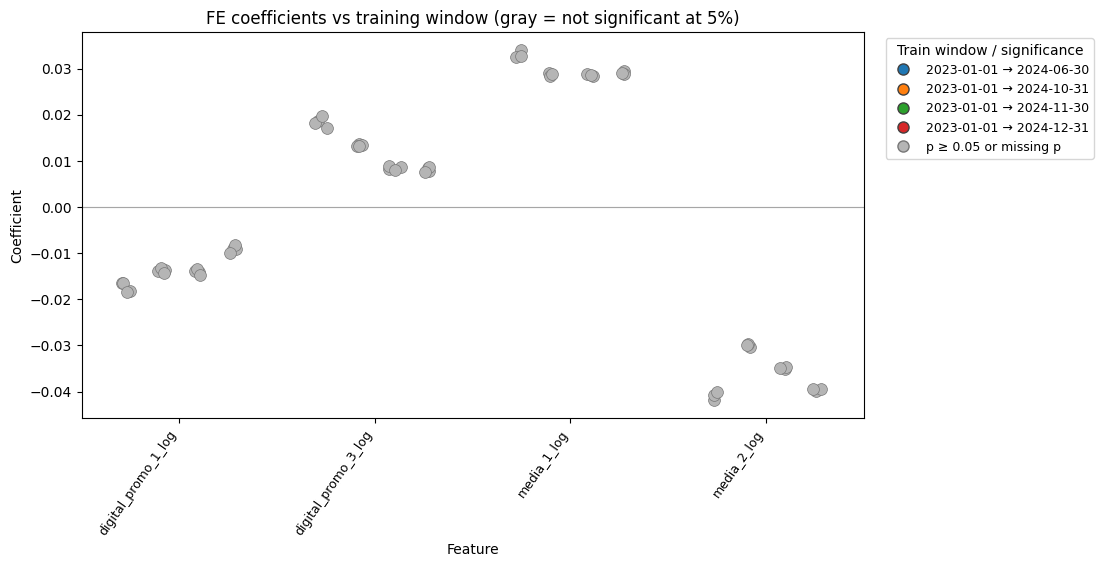

In [39]:
# FE coefficient stability across training windows — uses helper (see feature_engineering_helper.plot_consolidated_coef_stability_by_window)
import importlib

import matplotlib.pyplot as plt
import feature_engineering_helper as feh

importlib.reload(feh)

# Feature list for x-axis (reuse `feature_blocks` from the search cell if defined)
_fb = globals().get("feature_blocks")
if _fb is not None:
    chart_features = list(_fb["digital_promo"]) + list(_fb["media"])
else:
    chart_features = [
        *[f"digital_promo_{i}_log" for i in range(1, 6) if i != 2],
        *[f"media_{i}_log" for i in range(1, 6) if i != 5],
    ]

print(chart_features)

if "consolidated_coef_df" not in globals() or consolidated_coef_df is None or len(consolidated_coef_df) == 0:
    raise RuntimeError("Run the consolidated coefficients cell first.")

fig, ax = feh.plot_consolidated_coef_stability_by_window(
    consolidated_coef_df,
    chart_features,
    panel_control="fe",
    title="FE coefficients vs training window (gray = not significant at 5%)",
    legend="right"
)
plt.show()


In [29]:
consolidated_coef_df[consolidated_coef_df["panel_control"] == "fe"]

,feature,coef,t_stat,p_value,abs_coef,sign,rank_abscoef,is_significant_05,y_col,panel_control,algorithm,feature_block_set_id,time_split_id,train_start,train_end,test_start,test_end,run_id
13,seas_sin1,-0.056019,-1.885729,0.059706,0.056019,-1,1,False,GC_log,fe,OLS,kperblock__0004,train2024_only__test2025_H1,2023-01-01,2024-06-30,2025-01-01,2025-06-30,8fc45781079345808f25f948ea85fecc
14,media_2_log,-0.041910,-1.235416,0.217050,0.041910,-1,2,False,GC_log,fe,OLS,kperblock__0004,train2024_only__test2025_H1,2023-01-01,2024-06-30,2025-01-01,2025-06-30,8fc45781079345808f25f948ea85fecc
15,seas_cos1,0.032364,0.680849,0.496171,0.032364,1,3,False,GC_log,fe,OLS,kperblock__0004,train2024_only__test2025_H1,2023-01-01,2024-06-30,2025-01-01,2025-06-30,8fc45781079345808f25f948ea85fecc
16,digital_promo_3_log,0.018594,0.644570,0.519397,0.018594,1,4,False,GC_log,fe,OLS,kperblock__0004,train2024_only__test2025_H1,2023-01-01,2024-06-30,2025-01-01,2025-06-30,8fc45781079345808f25f948ea85fecc
17,digital_promo_1_log,-0.018236,-0.606452,0.544393,0.018236,-1,5,False,GC_log,fe,OLS,kperblock__0004,train2024_only__test2025_H1,2023-01-01,2024-06-30,2025-01-01,2025-06-30,8fc45781079345808f25f948ea85fecc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,seas_sin1,-0.047336,-1.913310,0.055984,0.047336,-1,1,False,GC_log,fe,OLS,block__digital_promo,train2023_24__test2025_H1,2023-01-01,2024-12-31,2025-01-01,2025-06-30,d52075f5a3de4a8981c03acf6c16770c
364,seas_cos1,0.035497,0.777539,0.437018,0.035497,1,2,False,GC_log,fe,OLS,block__digital_promo,train2023_24__test2025_H1,2023-01-01,2024-12-31,2025-01-01,2025-06-30,d52075f5a3de4a8981c03acf6c16770c
365,digital_promo_1_log,-0.009892,-0.700137,0.483999,0.009892,-1,3,False,GC_log,fe,OLS,block__digital_promo,train2023_24__test2025_H1,2023-01-01,2024-12-31,2025-01-01,2025-06-30,d52075f5a3de4a8981c03acf6c16770c
366,digital_promo_3_log,0.007680,0.301913,0.762779,0.007680,1,4,False,GC_log,fe,OLS,block__digital_promo,train2023_24__test2025_H1,2023-01-01,2024-12-31,2025-01-01,2025-06-30,d52075f5a3de4a8981c03acf6c16770c


from the folder run:
mlflow ui --backend-store-uri file:./mlruns_experiment

Then open http://127.0.0.1:5000 in a browser.

Pick experiment analysis_work_flow_panel (that’s experiment_name in your cell).
Open the parent run named grid_fe_mundlak — nested runs are the trials (feature set × fe / mundlak).